In [ ]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
df = pd.read_csv('/kaggle/input/rsna-bone-age/boneage-training-dataset.csv')
df.head()

In [ ]:
df.shape

In [7]:
sns.set_style("darkgrid")

<Axes: xlabel='male', ylabel='count'>

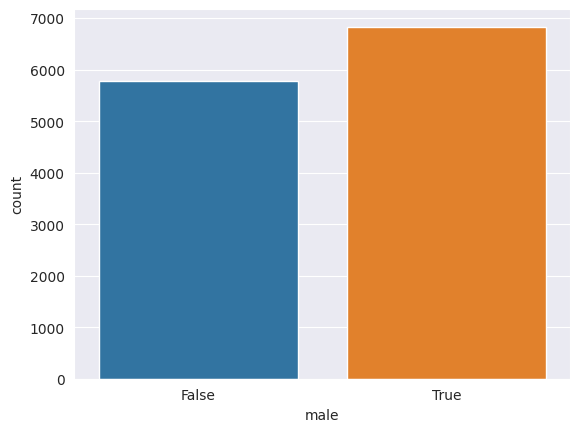

In [8]:
sns.countplot(df, x='male')

In [9]:
px.histogram(df, x='boneage')

# Images Preparation

In [10]:
df['id'] = df['id'].apply(lambda x: str(x) + '.png')

In [11]:
df.head()

,id,boneage,male
0,1377.png,180,False
1,1378.png,12,False
2,1379.png,94,False
3,1380.png,120,True
4,1381.png,82,False


In [12]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size = 0.15, random_state = 0)

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from  keras.applications.xception import preprocess_input 

img_size = 256

train_data_generator = ImageDataGenerator(
    rescale=1./255,
#     rotation_range=10, # rotation
#     width_shift_range=0.2, # horizontal shift
#     height_shift_range=0.2, # vertical shift
#     zoom_range=0.2, # zoom
#     horizontal_flip=True, # horizontal flip
#     brightness_range=[0.2,1.2],
    validation_split=0.3
)
test_data_generator = ImageDataGenerator(
    rescale=1./255,
)

train_data = train_data_generator.flow_from_dataframe(
    dataframe = df_train,
    directory = '/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset',
    x_col= 'id',
    y_col= 'boneage',
    batch_size = 32,
    seed = 42,
    shuffle = True,
    class_mode= 'other',
    flip_vertical = True,
    color_mode = 'grayscale',
    target_size = (img_size, img_size)
)

val_data = train_data_generator.flow_from_dataframe(
    dataframe = df_train,
    directory = '/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset',
    x_col = 'id',
    y_col = 'boneage',
    batch_size = 32,
    seed = 42,
    shuffle = True,
    class_mode = 'other',
    flip_vertical = True,
    color_mode = 'grayscale',
    target_size = (img_size, img_size),
    subset='validation'
)

test_data = test_data_generator.flow_from_dataframe(
    dataframe = df_test,
    directory = '/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset',
    x_col = 'id',
    y_col = 'boneage',
    shuffle = False,
    class_mode = 'other',
    color_mode = 'grayscale',
    target_size = (img_size,img_size)
)

Found 10719 validated image filenames.
Found 3215 validated image filenames.
Found 1892 validated image filenames.


In [14]:
for b in train_data:
    for _ in range(1):
        print(b[0].shape)
    break

(32, 256, 256, 1)


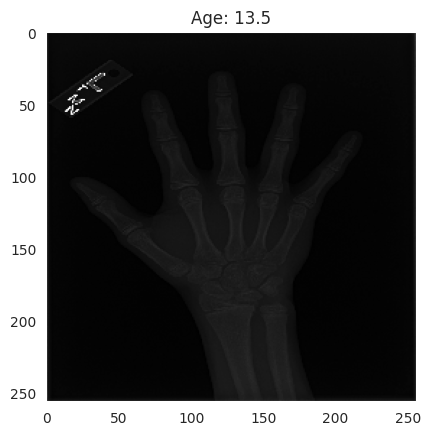

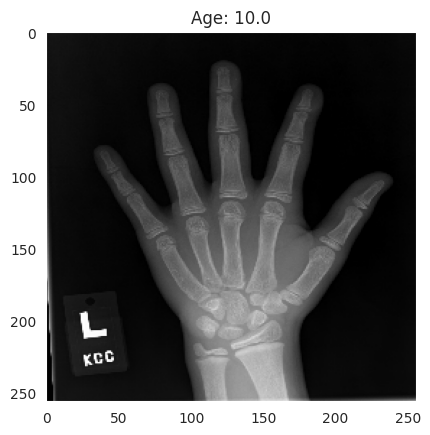

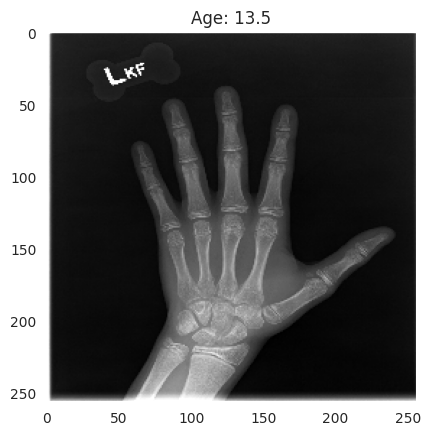

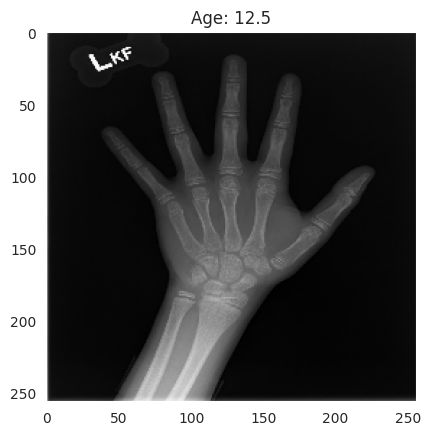

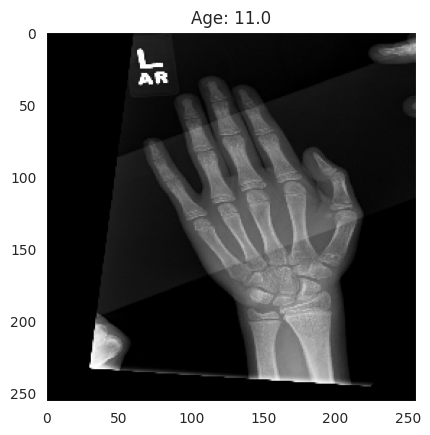

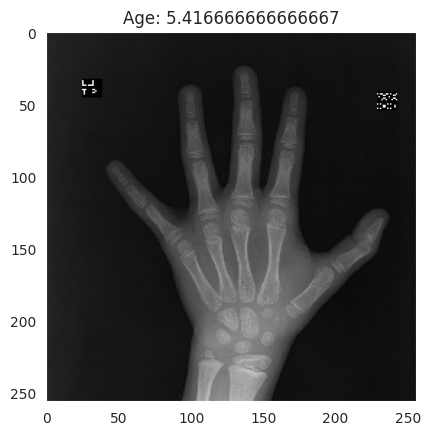

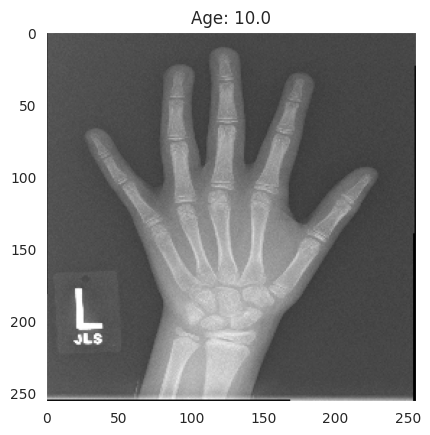

In [15]:
for batch in train_data:
    for i in range(5, 12):
        plt.imshow(batch[0][i], cmap='gray')
        plt.title(f'Age: {batch[1][i]/12}')
        plt.grid(False)
        plt.show()
    break

# Modeling

In [16]:
%%capture
!pip install wandb

In [17]:
import wandb
from wandb.keras import WandbCallback

In [18]:
run = wandb.init(
                project = 'bone_age_prediction',
                name= 'Model_04',
                config={
                    'architecture': 'Sequential',
                    'parent': 'Model_03',
                    'batchNormalization': True,
                    'kernel_size': 4,
                    'output_activation': 'linear',
                    'optimizer': 'Adamax',
                    'loss_function': 'mse',
                    'epochs': 60,
})

config = wandb.config

tf.keras.backend.clear_session()

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [19]:
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, Dense
from sklearn.metrics import r2_score
from keras import Sequential

In [20]:
def conv_bloc(num_filters, prev_layer):
    x = Conv2D(num_filters, kernel_size=4, use_bias=False, padding='same')(prev_layer)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

In [21]:
inputs = layers.Input(shape=(256, 256, 1))

x = conv_bloc(32, inputs)
x = conv_bloc(32, x)
x = layers.MaxPool2D()(x)

x = conv_bloc(64, x)
x = conv_bloc(64, x)
x = layers.MaxPool2D()(x)

x = conv_bloc(128, x)
x = conv_bloc(128, x)
x = conv_bloc(128, x)
x = layers.MaxPool2D()(x)

x = conv_bloc(256, x)
x = conv_bloc(256, x)
x = conv_bloc(256, x)
x = layers.MaxPool2D()(x)

x = conv_bloc(512, x)
x = conv_bloc(512, x)
x = conv_bloc(512, x)
x = layers.MaxPool2D()(x)

x = layers.Flatten()(x)

# x = Dense(1024, activation='relu')(x)
# x = Dense(512, activation='relu')(x)
# x = Dense(256, activation='relu')(x)
# x = Dense(128, activation='relu')(x)
# x = Dense(64, activation='relu')(x)
# x = Dense(32, activation='relu')(x)
# x = Dense(16, activation='relu')(x)

outputs = Dense(1, activation='linear')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# xception = tf.keras.applications.xception.Xception(input_shape = (256, 256, 3),
#                                            include_top = False,
#                                            weights = 'imagenet')
# xception.trainable = True
# model = Sequential()
# model.add(xception)
# # model.add(layers.GlobalMaxPooling2D())
# # model.add(Dense(10, activation = 'relu'))
# model.add(layers.MaxPool2D())
# model.add(layers.Flatten())
# model.add(Dense(1, activation = 'linear'))

# opt = keras.optimizers.SGD(learning_rate=0.001)

model.compile(
    optimizer='adamax',
    loss='mse',
    metrics=['mae']
)

print(model.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 256, 256, 32)      512       
                                                                 
 batch_normalization (BatchN  (None, 256, 256, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 256, 256, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 256, 256, 32)      16384     
                                                                 
 batch_normalization_1 (Batc  (None, 256, 256, 32)     128       
 hNormalization)                                             

In [164]:
# %%capture
# pip install pydot

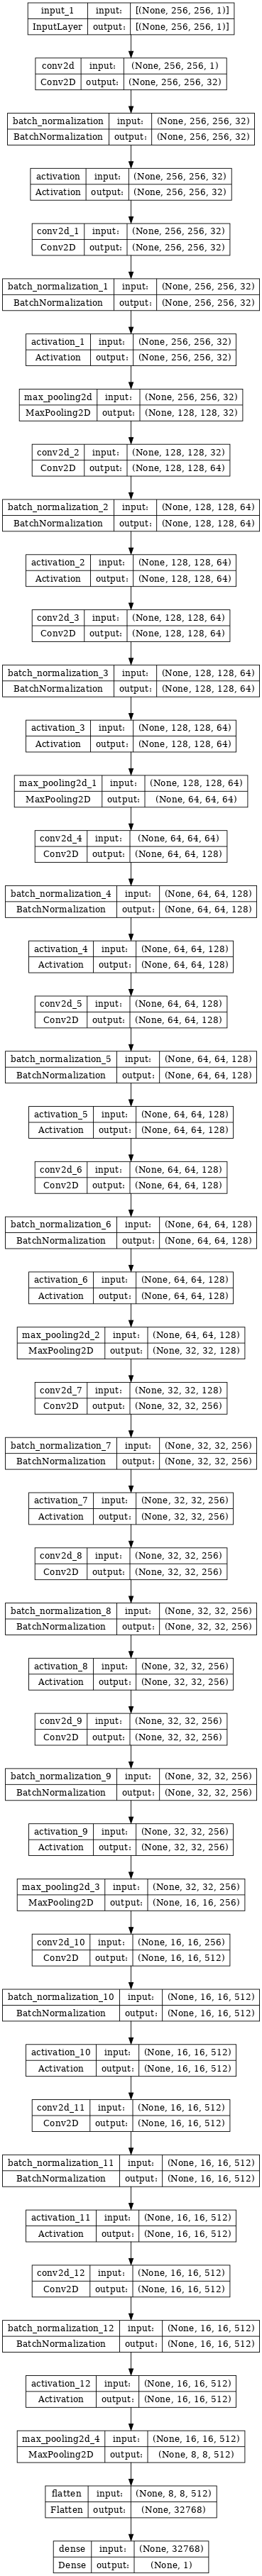

In [22]:
from keras.utils import plot_model

plot_model(model, show_shapes=True, dpi=64)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',
                              min_delta=0,
                              patience= 6,
                              verbose=0, mode='auto')

In [24]:
history = model.fit(
    train_data,
    epochs = config.epochs,
    callbacks= [WandbCallback(), early_stopping],
    validation_data = val_data,
)

wandb: WARNING The save_model argument by default saves the model in the HDF5 format that cannot save custom objects like subclassed models and custom layers. This behavior will be deprecated in a future release in favor of the SavedModel format. Meanwhile, the HDF5 model is saved as W&B files and the SavedModel as W&B Artifacts.


Epoch 1/60
335/335 [==============================] - ETA: 0s - loss: 1187.8582 - mae: 26.7205

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20231227_212044-69z2jubo/files/model-best)... Done. 0.7s


335/335 [==============================] - 533s 2s/step - loss: 1187.8582 - mae: 26.7205 - val_loss: 1849.7314 - val_mae: 33.3152
Epoch 2/60
335/335 [==============================] - ETA: 0s - loss: 678.2688 - mae: 20.0232

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20231227_212044-69z2jubo/files/model-best)... Done. 0.7s


...

335/335 [==============================] - 393s 1s/step - loss: 54.2966 - mae: 5.8016 - val_loss: 44.9366 - val_mae: 5.3299
Epoch 27/60
335/335 [==============================] - ETA: 0s - loss: 45.0503 - mae: 5.2847

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20231227_212044-69z2jubo/files/model-best)... Done. 0.6s


335/335 [==============================] - 391s 1s/step - loss: 45.0503 - mae: 5.2847 - val_loss: 34.3501 - val_mae: 4.6214
Epoch 28/60
335/335 [==============================] - ETA: 0s - loss: 42.7114 - mae: 5.1379

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20231227_212044-69z2jubo/files/model-best)... Done. 0.6s


335/335 [==============================] - 395s 1s/step - loss: 42.7114 - mae: 5.1379 - val_loss: 26.0550 - val_mae: 3.9611
Epoch 29/60
335/335 [==============================] - 382s 1s/step - loss: 44.0021 - mae: 5.2386 - val_loss: 68.4461 - val_mae: 6.5743
Epoch 30/60
335/335 [==============================] - 383s 1s/step - loss: 39.5808 - mae: 4.9562 - val_loss: 114.6585 - val_mae: 9.2808
Epoch 31/60
335/335 [==============================] - 383s 1s/step - loss: 37.1783 - mae: 4.8410 - val_loss: 50.1753 - val_mae: 5.8304
Epoch 32/60
335/335 [==============================] - 383s 1s/step - loss: 39.1983 - mae: 4.9472 - val_loss: 45.9025 - val_mae: 5.3902
Epoch 33/60
335/335 [==============================] - 382s 1s/step - loss: 30.4186 - mae: 4.3165 - val_loss: 36.5305 - val_mae: 4.8641
Epoch 34/60
335/335 [==============================] - 383s 1s/step - loss: 33.7897 - mae: 4.5936 - val_loss: 97.0350 - val_mae: 8.5990


In [25]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_mae = history.history['mae']
val_mae = history.history['val_mae']

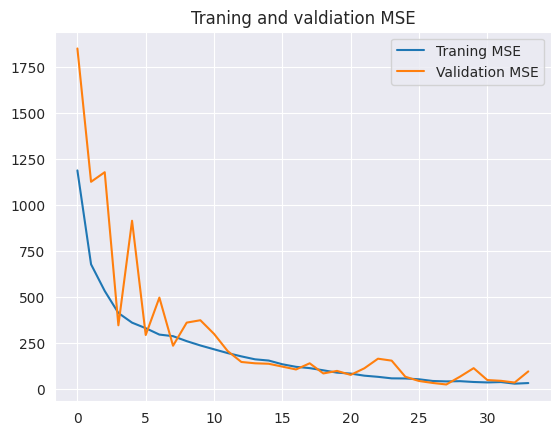

In [26]:
plt.plot(train_loss, label='Traning MSE')
plt.plot(val_loss, label='Validation MSE')
plt.title('Traning and valdiation MSE')
plt.legend()
plt.show()

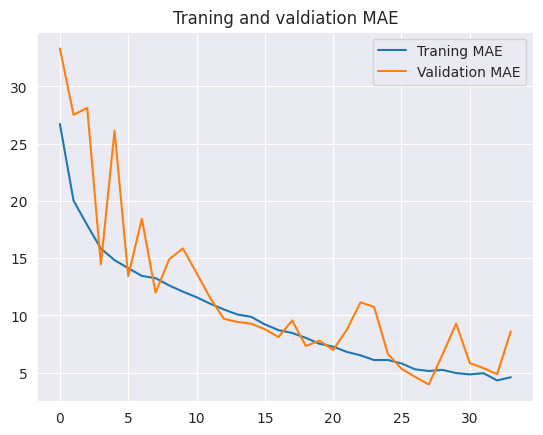

In [27]:
plt.plot(train_mae, label='Traning MAE')
plt.plot(val_mae, label='Validation MAE')
plt.title('Traning and valdiation MAE')
plt.legend()
plt.show()

In [28]:
type(test_data)

keras.preprocessing.image.DataFrameIterator

1/1 [==============================] - 0s 274ms/step
32


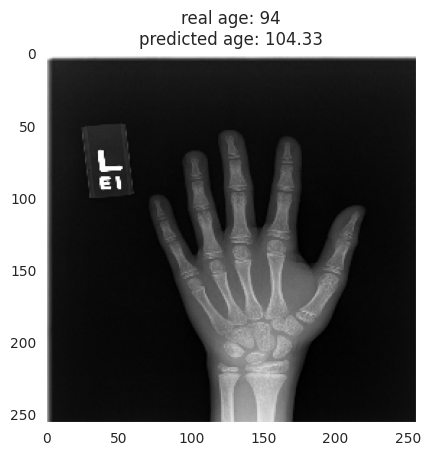

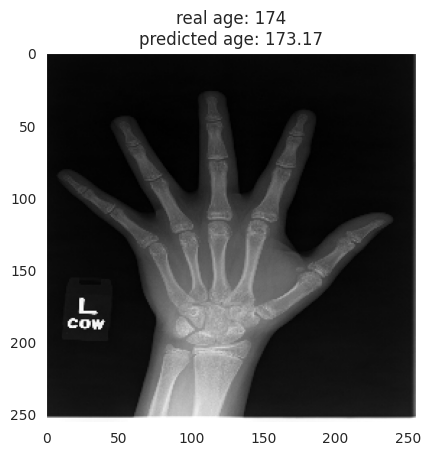

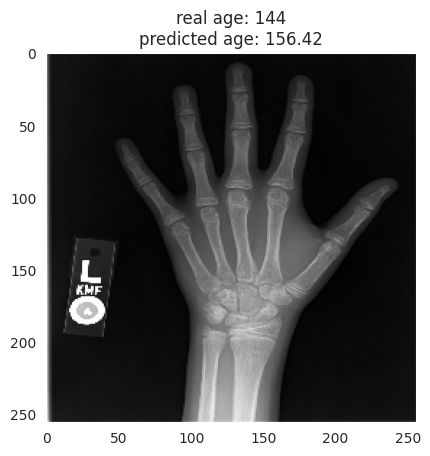

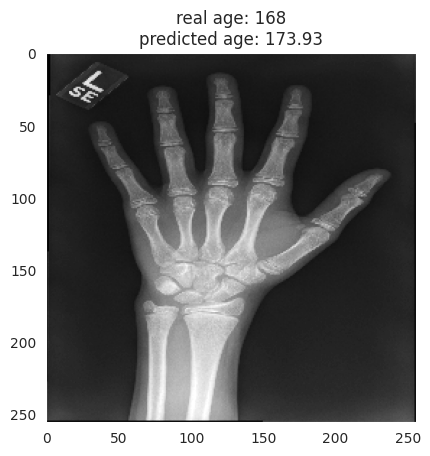

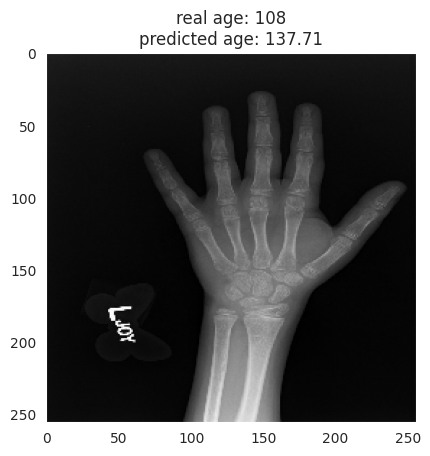

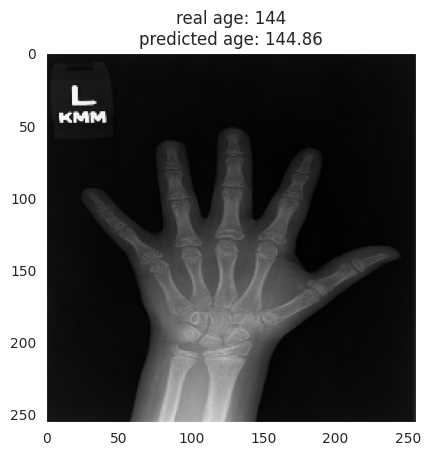

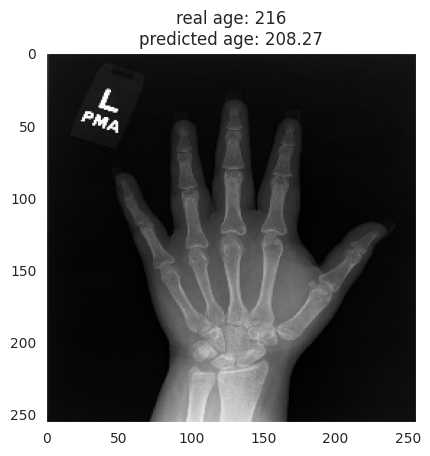

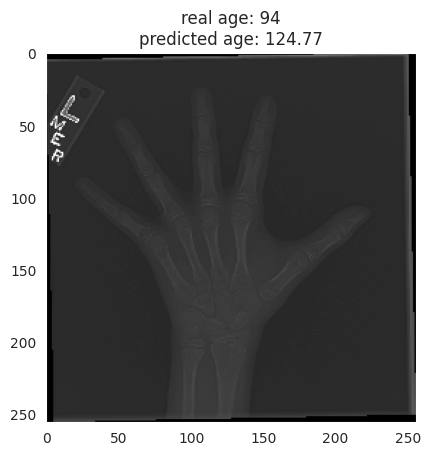

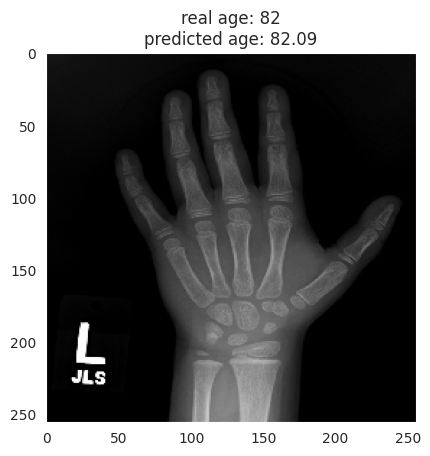

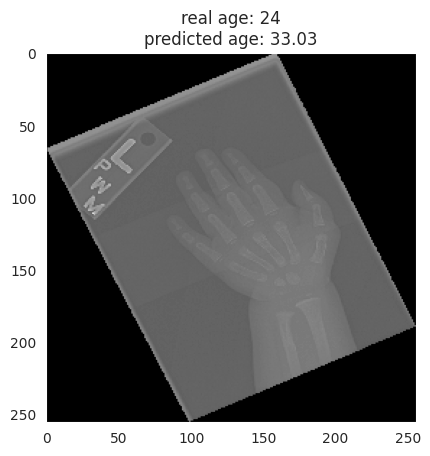

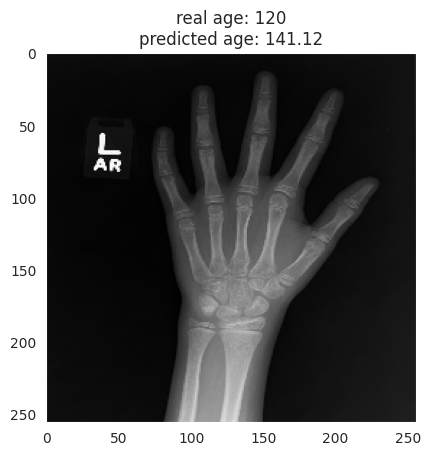

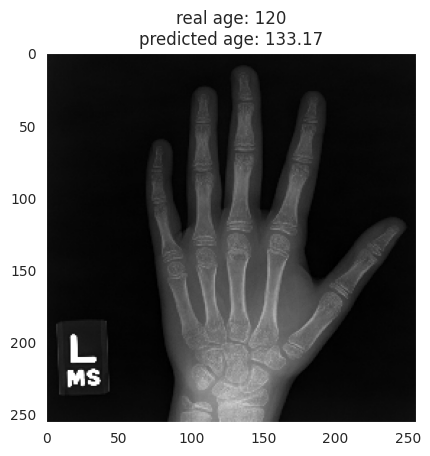

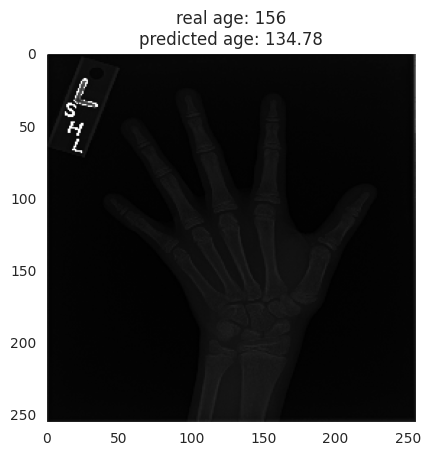

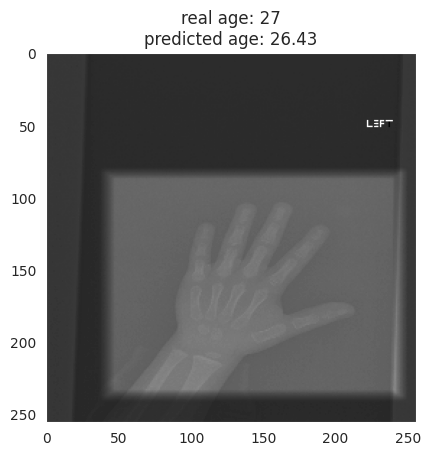

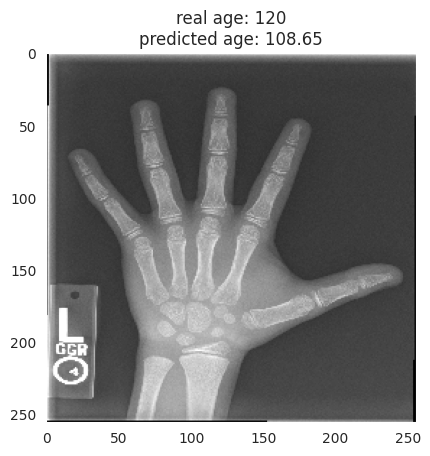

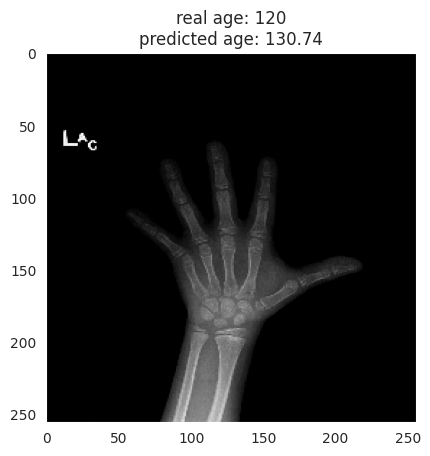

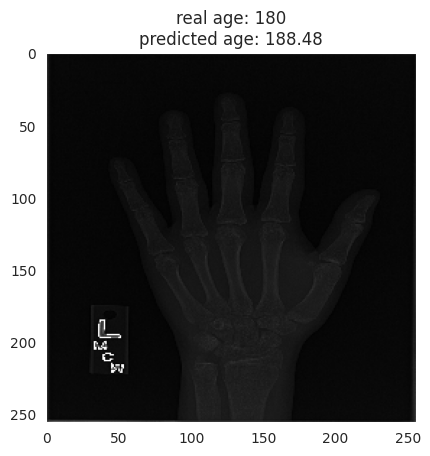

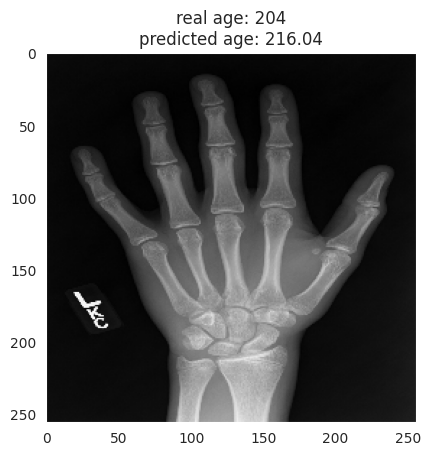

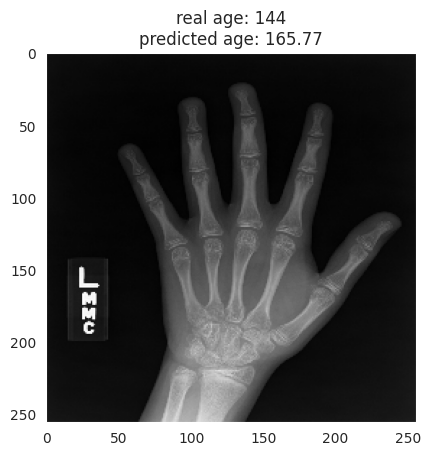

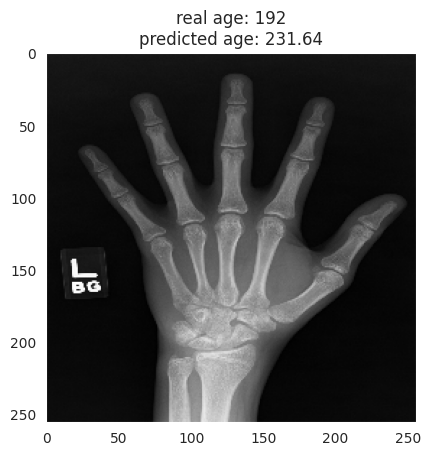

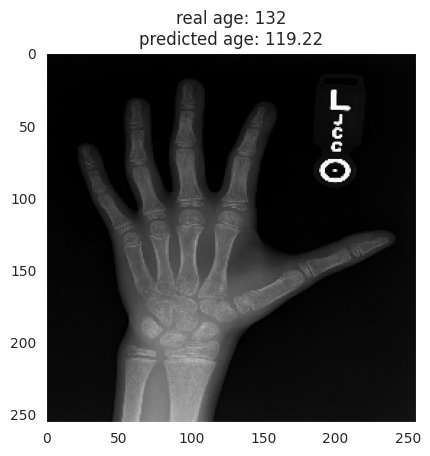

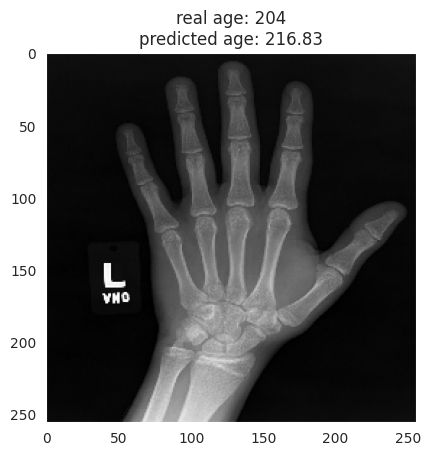

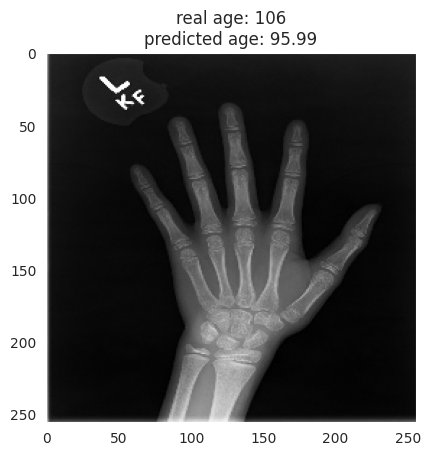

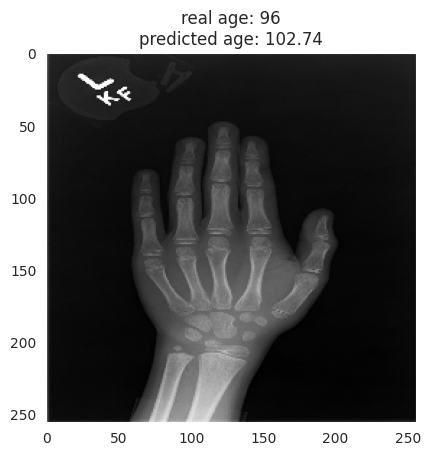

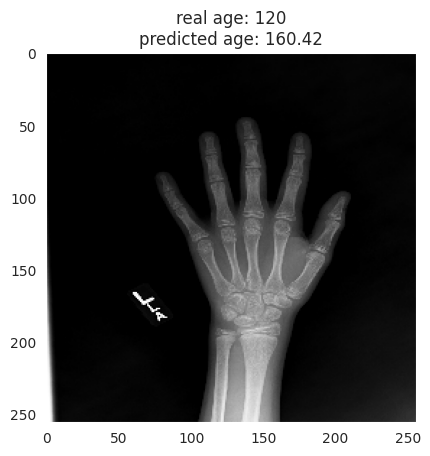

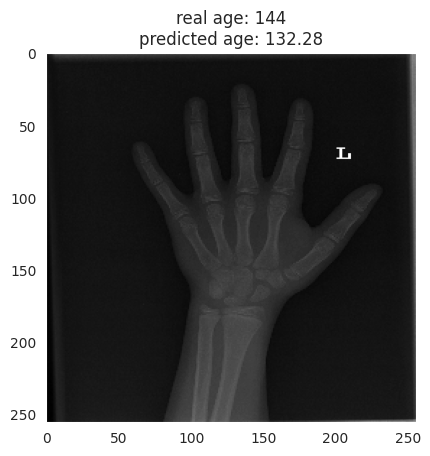

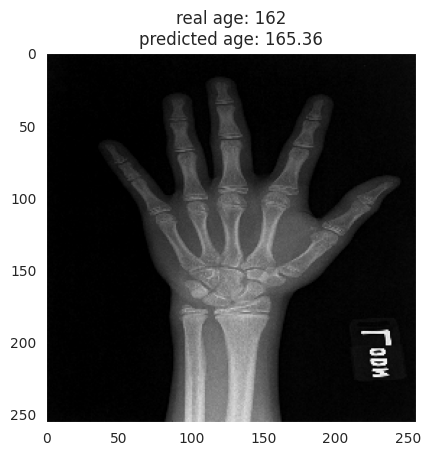

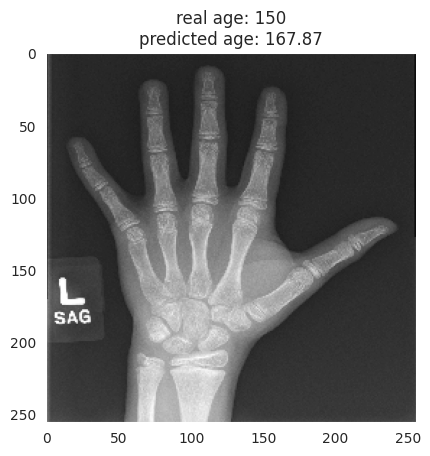

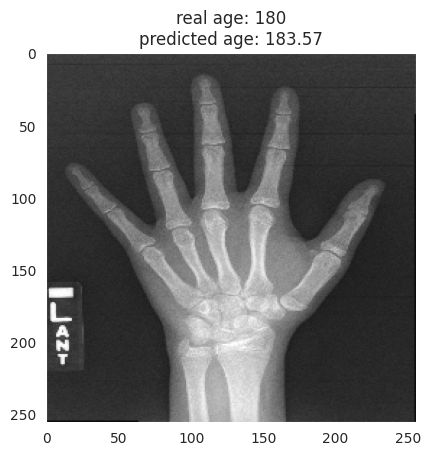

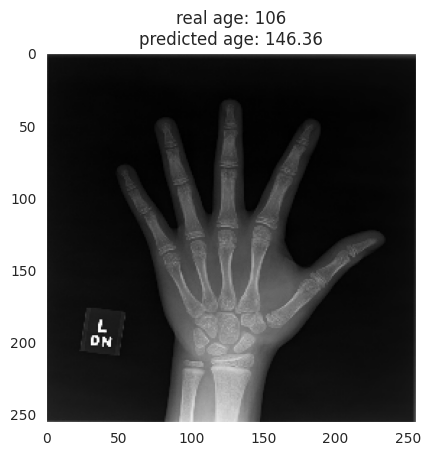

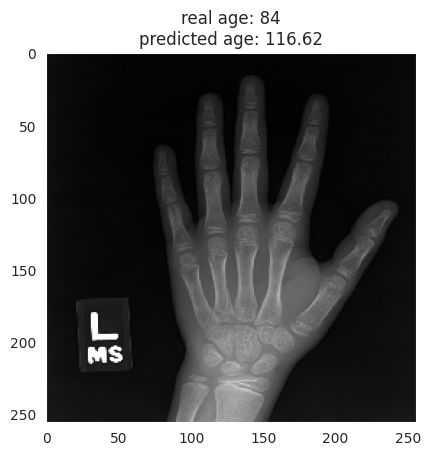

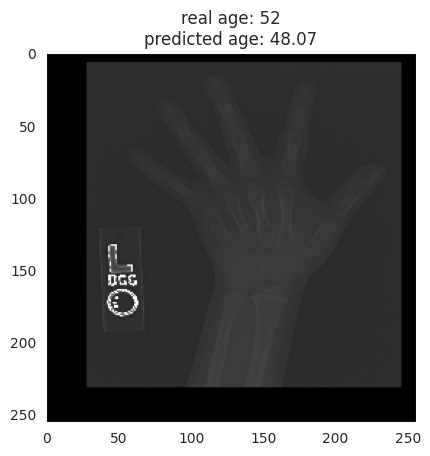

In [29]:
for x, y in test_data:
    actual = y
    predicted = model.predict(x)
    print(len(x))
    for i in range(32):
        plt.imshow(x[i], cmap='gray')
        plt.title(f'real age: {y[i]}\npredicted age: {predicted[i][0]:.2f}')
        plt.grid(False)
        plt.show()
    break

In [30]:
predicted = model.predict(test_data)

60/60 [==============================] - 73s 1s/step


Text(0, 0.5, 'Predicted Age (Months)')

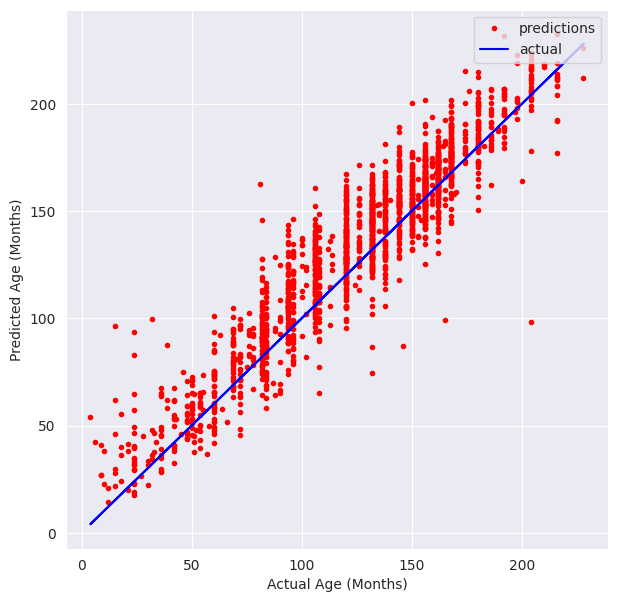

In [31]:
actual = df_test['boneage']

fig, ax = plt.subplots(figsize = (7,7))
ax.plot(actual, predicted, 'r.', label = 'predictions')
ax.plot(actual, actual, 'b', label = 'actual')
ax.legend(loc = 'upper right')
ax.set_xlabel('Actual Age (Months)')
ax.set_ylabel('Predicted Age (Months)')

In [32]:
model.save('Model_04.h5')